In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
#from Utils import weighted_annual_resample
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

In [2]:
from config import path_archive, ens_mems_arise_UK, ens_mems_CE, models, model_names

In [3]:
from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds, get_ssp245_ds

In [4]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))
ds_HiLLA_15_UK = get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))

## repeat for CESM
ds_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).load()
ds_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).load()

## and E3SM
ds_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))
ds_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069'))


## also get ssp245 for UKESM and CESM
ds_ssp245_UK = get_ssp245_ds(model='UKESM1-0-LL', centre='MOHC', variable='tas', 
                                 members=ens_mems_arise_UK, table='Amon', grid='gn').mean('Ensemble_member').load()

ds_ssp245_CE = get_ssp245_ds(model='CESM2-WACCM', centre='NCAR', variable='tas', 
                             members=ens_mems_CE, table='Amon', grid='gn').mean('Ensemble_member').load()


## also get preindustrial, for comparison:
path = '/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/Amon/tas/gn/latest/'
ds_PI_UK = xr.open_mfdataset(path+'*.nc').rename({'lon':'longitude', 'lat':'latitude'})
ds_PI_UK = ds_PI_UK.mean('longitude').isel(time=slice(0, 600)).groupby("time.month").mean(dim="time").load()

path = '/badc/cmip6/data/CMIP6/CMIP/NCAR/CESM2-WACCM/piControl/r1i1p1f1/Amon/tas/gn/latest/'
ds_PI_CE = xr.open_mfdataset(path+'*.nc').rename({'lon':'longitude', 'lat':'latitude'})
ds_PI_CE = ds_PI_CE.mean('longitude').isel(time=slice(0, 600)).groupby("time.month").mean(dim="time").load()


### + ARISE
ds_list_tas = []
paths_tas = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/')

for path in paths_tas:
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).rename({'x':'longitude', 'y':'latitude'})
    ds_list_tas.append(ds)

ds_arise_UK = xr.concat(ds_list_tas, dim='Ensemble_member').mean('Ensemble_member')

## CE
ds_list_tas = []
path = '/gws/nopw/j04/cpom/aduffey/ARISE/CESM/arise/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]
# we keep only first 5 members to align with the ssp245 runs available
# this also means there are 5 members for both models, making figures easier to interpret
files = [x for x in files if int(x.split('.')[5]) < 6] 
for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file)).rename({'x':'longitude', 'y':'latitude'})
    ds = set_time_to_center_of_bounds(ds)
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list_tas.append(ds)
ds_arise_CE = xr.concat(ds_list_tas, dim='Ensemble_member')
#ds_arise_CE = set_time_to_center_of_bounds(ds_arise_CE) # needed as CESM direct output is weird, has time bounds correct, but time points themselves labelled by the end not start
ds_arise_CE = ds_arise_CE['TREFHT'].to_dataset(name='tas').mean('Ensemble_member')


## E3
ds_ssp245_E3 =  set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice('2015', '2069'))

In [5]:
### make monthly as 20-year mean
def process(ds, period_start='2051', period_end='2069'):
    ds = ds.mean('longitude')
    ds = ds.sel(time=slice(period_start, period_end))
    return ds.groupby("time.month").mean(dim="time")

ds_HiLLA_13_UK = process(ds_HiLLA_13_UK).load()
ds_HiLLA_15_UK = process(ds_HiLLA_15_UK).load()

ds_HiLLA_13_CE = process(ds_HiLLA_13_CE).load()
ds_HiLLA_15_CE = process(ds_HiLLA_15_CE).load()

ds_HiLLA_13_E3 = process(ds_HiLLA_13_E3).load()
ds_HiLLA_15_E3 = process(ds_HiLLA_15_E3).load()


ds_arise_UK = process(ds_arise_UK).load()
ds_arise_CE = process(ds_arise_CE).load()

ds_ssp245_UK = process(ds_ssp245_UK).load()
ds_ssp245_CE = process(ds_ssp245_CE).load()


ds_ssp245_early_E3 = process(ds_ssp245_E3, period_start='2035', period_end='2050').load() # also get early period for E3
ds_ssp245_E3 = process(ds_ssp245_E3).load()


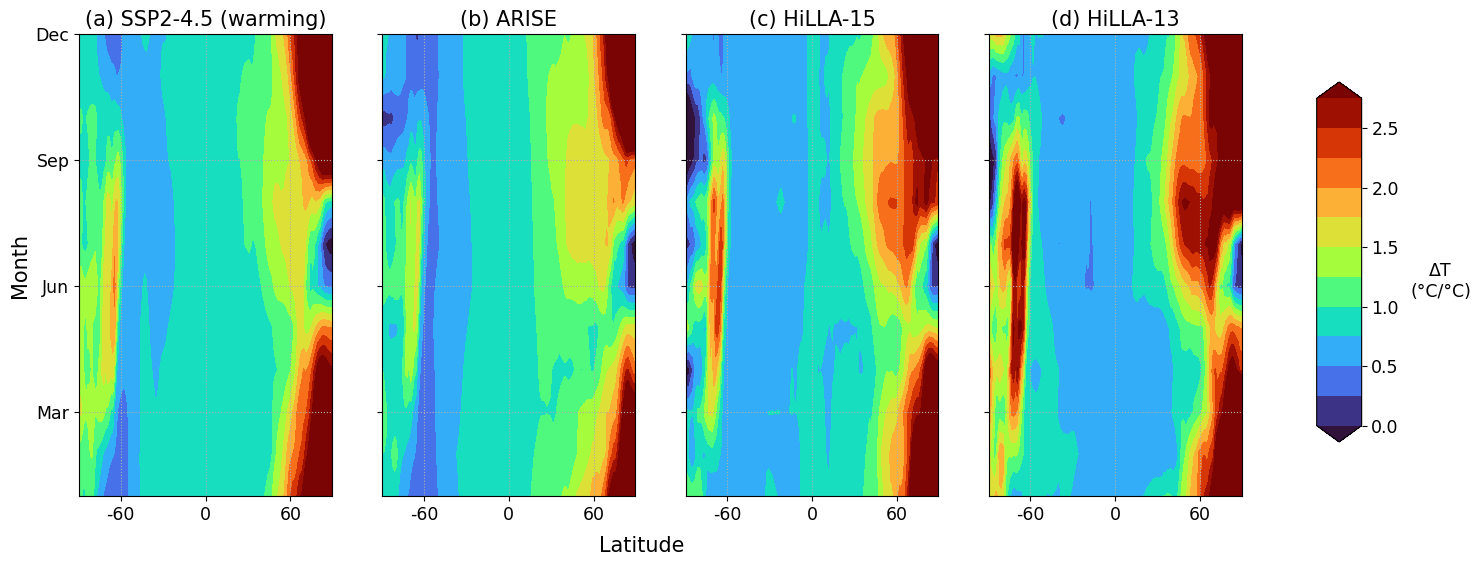

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(15, 6), sharey=True)

data_UK = [(ds_ssp245_UK - ds_PI_UK),
           -(ds_arise_UK - ds_ssp245_UK), 
           -(ds_HiLLA_15_UK - ds_ssp245_UK),
           -(ds_HiLLA_13_UK - ds_ssp245_UK)]


data_CE = [(ds_ssp245_CE- ds_PI_CE),
           (ds_arise_CE - ds_ssp245_CE), 
           (ds_HiLLA_15_CE - ds_ssp245_CE),
           (ds_HiLLA_13_CE - ds_ssp245_CE)]

i=0
titles=['(a) SSP2-4.5 (warming)', '(b) ARISE', '(c) HiLLA-15', '(d) HiLLA-13']
#for run in ['u-de365', 'u-dg331']:
for data in data_UK:
    ax = axs[i]
    
    cs=ax.contourf(data.latitude.values, data.month.values, 
                   data.tas.values/spatial_mean(data, 'Global', zonal_mean=True).mean('month').tas.item(),
                   levels = np.arange(0, 3, 0.25),
                   cmap='turbo',
                   extend='both')
    ax.set_xticks([-60, 0, 60])
    ax.set_xticklabels(['-60', '0', '60'], fontsize='small')
    ax.set_yticks([3, 6, 9, 12])
    ax.set_yticklabels(['Mar', 'Jun', 'Sep', 'Dec'], fontsize='small')
    ax.grid(ls='dotted')
    ax.set_title(titles[i], fontsize='medium')
    i=i+1
    
axs[0].set_ylabel('Month')
fig.supxlabel('Latitude', fontsize='medium')
#plt.tight_layout()
#cbar_ax1 = fig.add_axes([0.05, -0.05, 0.35, 0.04])
cbar_ax1 = fig.add_axes([0.95, 0.2, 0.03, 0.6])
cbar1 = fig.colorbar(cs, cax=cbar_ax1, orientation='vertical') 
                     #label='\u0394 F_SW \n(W/m2)')
                     #ticks=[-8, -6, -4, -2, -1, -0.1, 0.1, 1, 2, 4, 6, 8])
cbar1.set_label('\u0394T\n(°C/°C)', rotation=0, ha='center', labelpad=30, fontsize='small')
cbar1.ax.tick_params(labelsize='small')

plt.savefig('Figures/zonal_seasonal_cooling.jpg', dpi=350, bbox_inches='tight')
plt.show()

# make into spatial means and plot in 1D:

In [7]:
def process(ds):
    ds = spatial_mean(ds, 'Arctic', zonal_mean=True)
    return ds

ds_HiLLA_13_UK = process(ds_HiLLA_13_UK).load()
ds_HiLLA_15_UK = process(ds_HiLLA_15_UK).load()
ds_HiLLA_13_CE = process(ds_HiLLA_13_CE).load()
ds_HiLLA_15_CE = process(ds_HiLLA_15_CE).load()
ds_HiLLA_13_E3 = process(ds_HiLLA_13_E3).load()
ds_HiLLA_15_E3 = process(ds_HiLLA_15_E3).load()

ds_arise_UK = process(ds_arise_UK).load()
ds_arise_CE = process(ds_arise_CE).load()

ds_ssp245_UK = process(ds_ssp245_UK).load()
ds_ssp245_CE = process(ds_ssp245_CE).load()

ds_ssp245_early_E3 = process(ds_ssp245_early_E3).load()
ds_ssp245_E3 = process(ds_ssp245_E3).load()

ds_PI_UK = process(ds_PI_UK).load()
ds_PI_CE = process(ds_PI_CE).load()

In [8]:
warming_UK = (ds_ssp245_UK - ds_PI_UK).tas
coolings_UK = {'HiLLA-13':(ds_HiLLA_13_UK - ds_ssp245_UK).tas,
               'HiLLA-15':(ds_HiLLA_15_UK - ds_ssp245_UK).tas,
                'ARISE':(ds_arise_UK - ds_ssp245_UK).tas}


warming_CE = (ds_ssp245_CE - ds_PI_CE).tas
coolings_CE = {'HiLLA-13':(ds_HiLLA_13_CE - ds_ssp245_CE).tas,
               'HiLLA-15':(ds_HiLLA_15_CE - ds_ssp245_CE).tas,
               'ARISE':(ds_arise_CE - ds_ssp245_CE).tas}

warming_E3 = (ds_ssp245_E3 - ds_ssp245_early_E3).tas
coolings_E3 = {'HiLLA-13':(ds_HiLLA_13_E3 - ds_ssp245_E3).tas,
               'HiLLA-15':(ds_HiLLA_15_E3 - ds_ssp245_E3).tas,
               }

warmings = {'UKESM':warming_UK, 'CESM':warming_CE, 'E3SM':warming_E3}
coolings = {'UKESM':coolings_UK, 'CESM':coolings_CE, 'E3SM':coolings_E3}

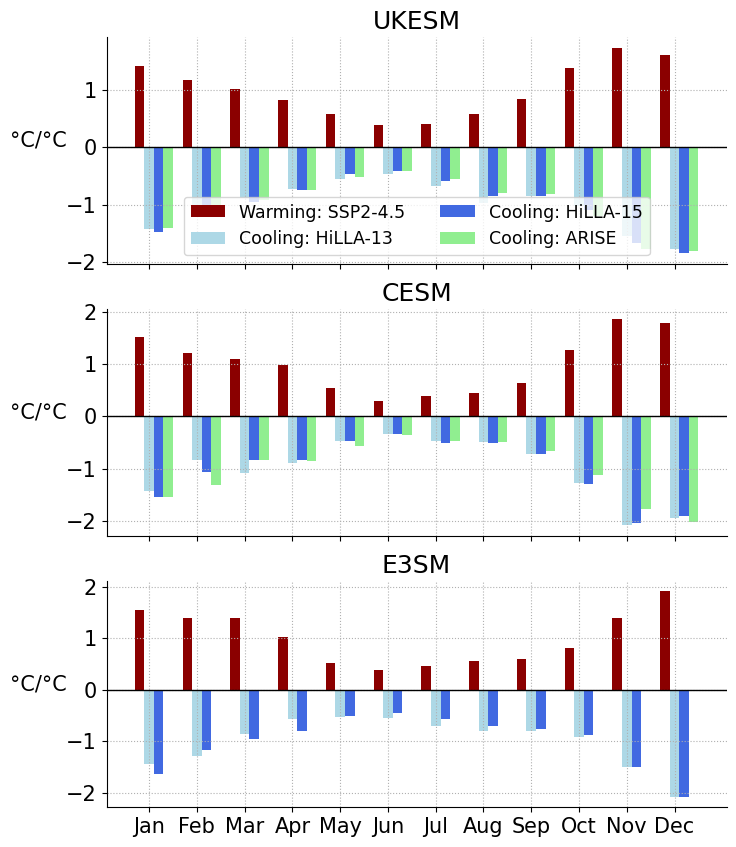

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

months = np.arange(1, 13)
colors=['lightblue', 'royalblue', 'lightgreen']
width = 0.2

a=0

for model in models:
    ax = axs[a]
    warming_values = warmings[model].values
    cooling_values_raw = {k: v.values for k, v in coolings[model].items()}
    
    # Calculate annual means
    warming_mean = warming_values.mean()
    cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}
    
    # Normalize: divide each month by its series mean
    warming_norm = warming_values / warming_mean
    cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                                  zip(cooling_values_raw.values(), cooling_means.values()))}
    
    
    # Plot warming bars (shifted left)
    ax.bar(months - width, warming_norm, width=width, label='Warming: SSP2-4.5', color='darkred')
    
    # Plot cooling bars (shifted right)
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])

    # Customize
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
    #ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
    axs[0].legend(loc='lower center', ncols=2, fontsize='small')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(model)
    a=a+1
    
plt.savefig('Figures/cooling_seasonality_all.jpg', dpi=300, bbox_inches='tight')

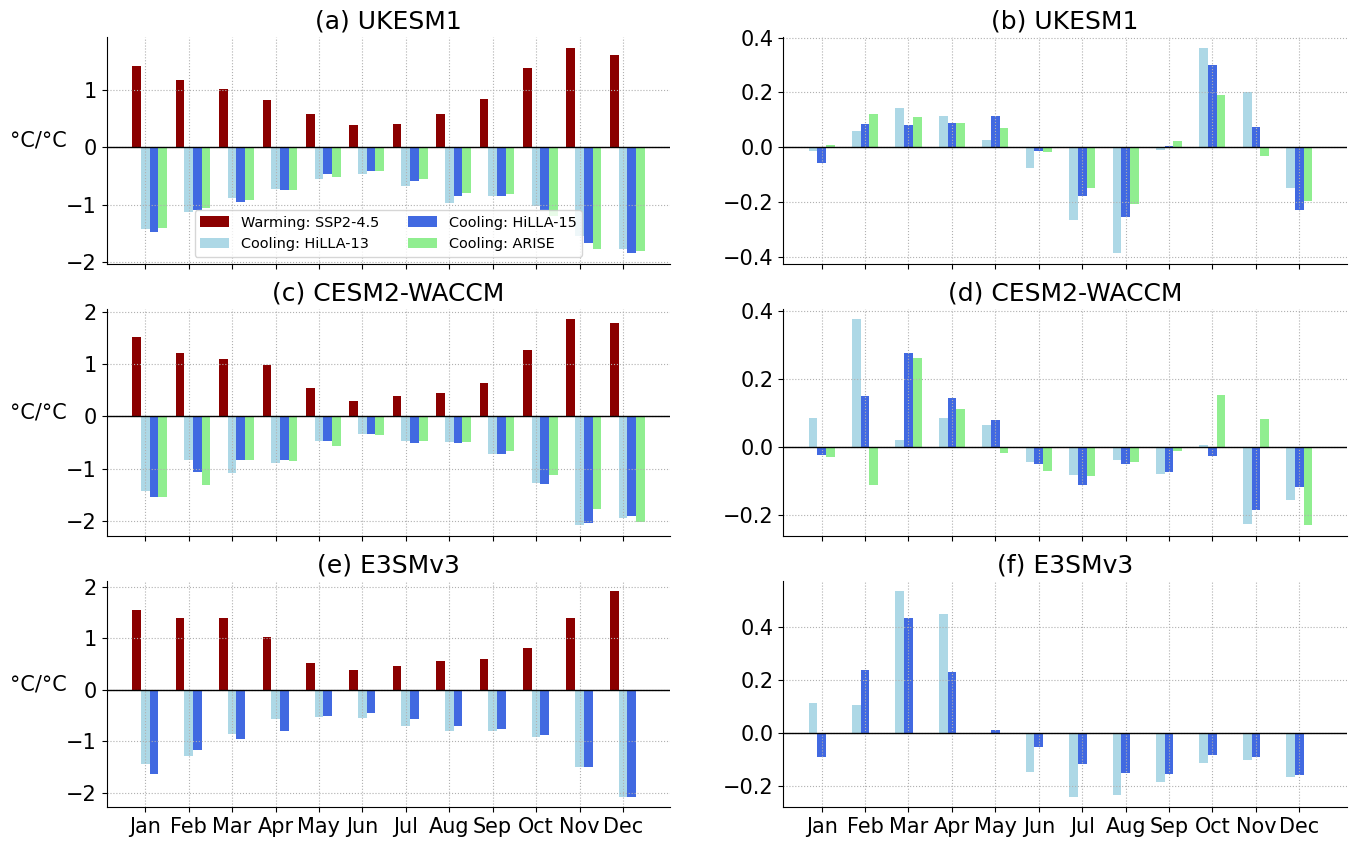

In [10]:
fig, axs = plt.subplots(3, 2, figsize=(16, 10), sharex=True)

months = np.arange(1, 13)
colors=['lightblue', 'royalblue', 'lightgreen']
width = 0.2
labs = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
a=0

for model in models:
    ax = axs[a, 0]
    warming_values = warmings[model].values
    cooling_values_raw = {k: v.values for k, v in coolings[model].items()}
    
    # Calculate annual means
    warming_mean = warming_values.mean()
    cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}
    
    # Normalize: divide each month by its series mean
    warming_norm = warming_values / warming_mean
    cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                                  zip(cooling_values_raw.values(), cooling_means.values()))}
    
    # Plot warming bars (shifted left)
    ax.bar(months - width, warming_norm, width=width, label='Warming: SSP2-4.5', color='darkred')
    
    # Plot cooling bars (shifted right)
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + i * width, values, width=width, label=f'Cooling: {name}', color=colors[i])
    ax.set_title(model)
    ax.set_ylabel('°C/°C', rotation=0, labelpad=20)
    ax.set_title(str(labs[2*a] + ' ' + model_names[model]))
    a=a+1

a=0
for model in models:
    ax = axs[a, 1]
    warming_values = warmings[model].values
    cooling_values_raw = {k: v.values for k, v in coolings[model].items()}
    
    # Calculate annual means
    warming_mean = warming_values.mean()
    cooling_means = {k: vals.mean() for k, vals in cooling_values_raw.items()}
    
    # Normalize: divide each month by its series mean
    warming_norm = warming_values / warming_mean
    cooling_norm = {k: (-vals / mean) for k, (vals, mean) in zip(cooling_values_raw.keys(),
                                                                  zip(cooling_values_raw.values(), cooling_means.values()))}
    
    for i, (name, values) in enumerate(cooling_norm.items()):
        ax.bar(months + (i-1)*width, values + warming_norm, width=width, label=f'Cooling: {name}', color=colors[i])
    ax.set_title(str(labs[2*a+1] + ' ' + model_names[model]))
    a=a+1

axs.flatten()[0].legend(loc='lower center', ncols=2, fontsize='x-small')
for ax in axs.flatten():
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xticks(months)
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    #ax.set_title('Monthly Warming and Cooling (Normalized per Annual Mean)')
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    
    
plt.savefig('Figures/cooling_seasonality_all.jpg', dpi=300, bbox_inches='tight')